# Chapter 1 &mdash; What Are Cellular Automata?

*Cellular Automata Dynamics &mdash; Python Edition*

This first notebook is mostly conceptual: it introduces what a
cellular automaton (CA) **is**, fixes the vocabulary used
throughout, and gives you a first runnable taste of each of the
four worlds we will visit (dimensions 0, 1, and 2, plus the
ecosystem). The later notebooks go deep on each.

A CA is a simple universe: a lattice of **cells**, each in one of
finitely many **states**, all updated **synchronously** by a
**transition rule** that looks only at a cell's **neighborhood**.
Simple local rules, iterated, produce startlingly complex global
behavior &mdash; the phenomenon of *emergence* that motivates the
whole book.

In [1]:
# Setup: put the cadyn package on the path and enable inline figures.
# If you installed the package (`pip install -e .` from the repo root),
# the sys.path line is unnecessary.
import sys, pathlib
repo = pathlib.Path.cwd()
for _ in range(4):                      # find the repo root from anywhere
    if (repo / "cadyn").is_dir():
        break
    repo = repo.parent
sys.path.insert(0, str(repo))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 5)

## The formal ingredients

To specify a CA you must give:

1. **A lattice** of cells (dimension $n$), here made finite with
   *periodic* (wrap-around) boundaries &mdash; a line becomes a
   circle, a plane becomes a torus.
2. **A neighborhood** for each cell (we use *homogeneous* CA: the
   same relative neighborhood everywhere).
3. **Transition rules** $T$ giving each cell's next state from its
   neighborhood's current states.

The dynamics are then fixed by the initial state $C_0$ together
with
$$ C_{t+1}(i_1,\dots,i_n) = T\bigl(N_t(i_1,\dots,i_n)\bigr). $$

Let's see one representative from each chapter.

### A 0-dimensional CA (Chapter 2): a single cell, $f(x)=x^2+1 \pmod{17}$

trajectory from 0: [0, 1, 2, 5, 9, 14, 10, 16, 2]


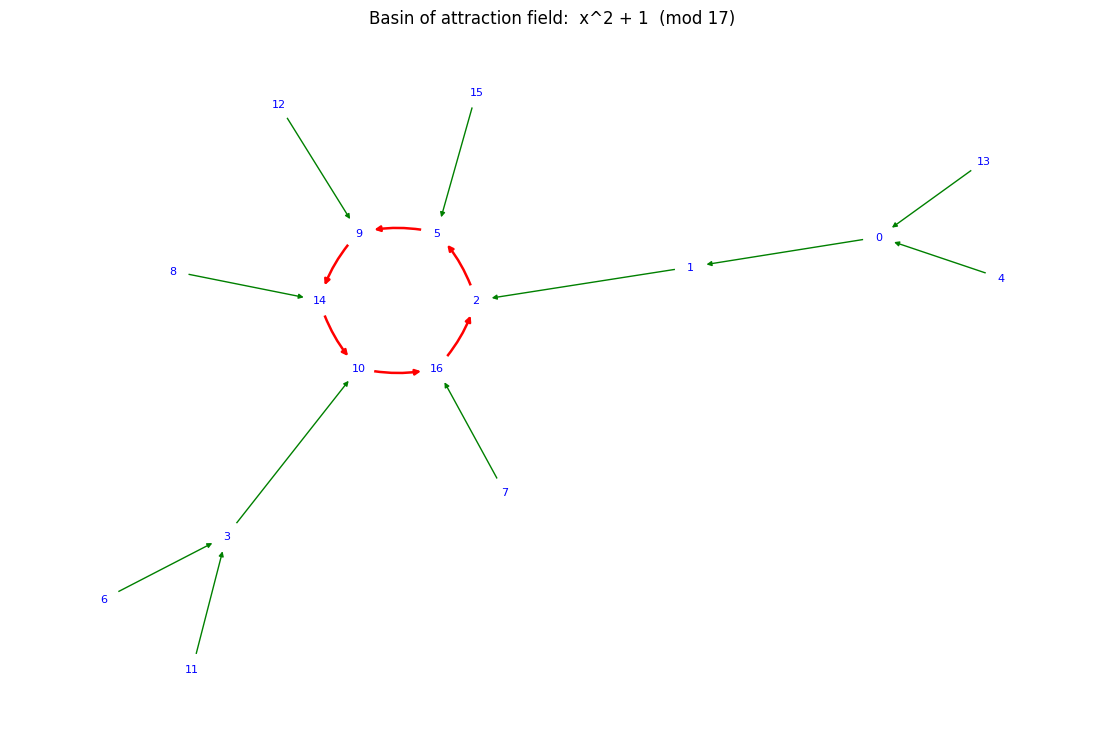

In [2]:
from cadyn import fds
s = fds.example_2_1()          # x^2 + 1 (mod 17)
print("trajectory from 0:", s.trajectory(0))
s.plot_basin_field()
plt.show()

### A 1-dimensional CA (Chapter 3): the rule $[1\,0\,1] \bmod 2$ makes a Sierpiński gasket

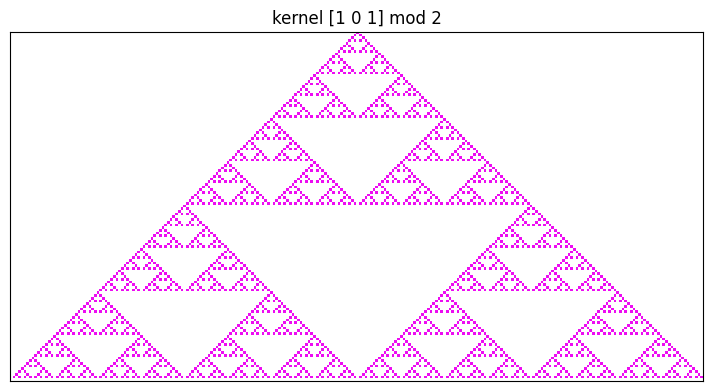

In [3]:
from cadyn import ca1d
hist = ca1d.run_additive(ca1d.single_seed(256), [1, 0, 1],
                         k=2, generations=128)
ca1d.plot_spacetime(hist, k=2, title="kernel [1 0 1] mod 2")
plt.show()

### A 2-dimensional CA (Chapter 4): Conway's Game of Life, age-colored

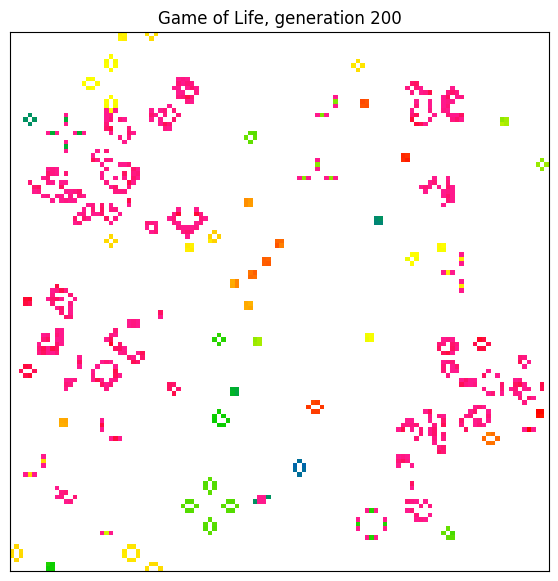

In [4]:
from cadyn import ca2d
alive0 = ca2d.random_life(120, p=0.3, rng=np.random.default_rng(0))
alive, age = ca2d.run_life(alive0, 200)
ca2d.show_life(age, title="Game of Life, generation 200")
plt.show()

### An ecosystem (Chapter 5): predator / prey / plants on a torus

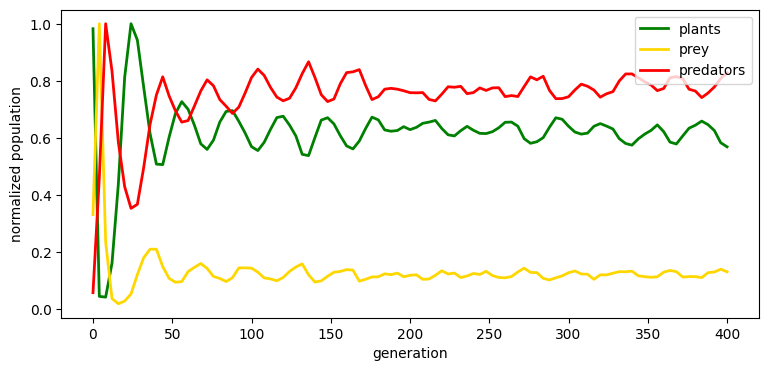

In [5]:
from cadyn.ecosystem import Ecosystem
eco = Ecosystem(n=120, rng=np.random.default_rng(1))
eco.run(400)
eco.plot_populations()
plt.show()

## Where to go next

Each remaining notebook takes one of these worlds and explores it
properly:

| Notebook | Module | Theme |
|---|---|---|
| 02 | `cadyn.fds` | finite dynamical systems, basins, entropy |
| 03 | `cadyn.ca1d` | 1-D CA, convolution kernels, fractals |
| 04 | `cadyn.ca2d` | 2-D CA, image processing, Life |
| 05 | `cadyn.ecosystem` | predator/prey dynamics |
| 06 | `cadyn.ca1d` | Wolfram's four classes, Rule 110 |
| 07 | `cadyn.evolution` | veridical perception & selection |

**Exercise.** Re-run the four demos above with different random
seeds and initial densities. Which worlds are sensitive to the
starting condition, and which settle to the same behavior
regardless?